# Malignant Glioma Pilot Study

## Dataset Overview

The `glioma` dataset, found within the **coin** R package, originates from a pilot study focusing on patients with malignant glioma who underwent pretargeted adjuvant radioimmunotherapy using yttrium-90-biotin. This dataset includes variables such as patient sex, treatment group, age, histology (tissue study), and survival time. For detailed attributes and dataset structure, refer to the dataset's documentation within the package.

## Objectives

This analysis aims to investigate the following aspects:

a. **Sex and Group Interaction on Survival Time:** Determine whether there is an interaction between patient sex and treatment group that significantly impacts the survival time (`time`).

b. **Age and Histology Interaction on Survival Time:** Assess if age and histology interact in a way that influences the survival time of patients.

c. **Comprehensive Data Exploration:** Conduct an exhaustive graphical examination of the dataset to uncover any additional patterns or relationships that merit statistical investigation. Identify the most compelling and insightful observation, formulate a relevant hypothesis, and perform the appropriate statistical analysis.

## Instructions

In the biostatistics sections of this site, we will be adhering to the following guidelines in order to answer the questions on our objectives:

* **Testing Assumptions:** For all questions necessitating formal inferential statistics, I will conduct and document the appropriate preliminary tests to check statistical assumptions. This includes stating the assumptions, detailing the procedures for testing these assumptions, and specifying the null hypotheses ($H_{0}$). If assumptions are tested graphically, I will elucidate the rationale behind the graphical method. I will also discuss the outcomes of these assumption tests and provide a rationale for the chosen inferential statistical tests (e.g., *t*-test, ANOVA).

* **State Hypotheses:** When inferential statistics are employed, I will clearly articulate the null ($H_{0}$) and alternative ($H_{A}$) hypotheses. 

* **Graphical Support:** Support all descriptive and inferential statistical analyses with appropriate graphical representations of the data.

* **Formatting:** Presentation matters. The visual quality of the page will be made to my utmost best. This includes the neatness of the document, proper use of headings, and adherence to coding conventions (e.g., spacing).

Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [9]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

### a. Sex and Group Interaction on Survival Time

Given that we are still working with the same package installed in the first section, we will just load the data and view it structure, skipping the installation phase:

In [12]:
# Load the glioma dataset

library(tidyverse)
library(coin)
data(glioma, package = "coin")

In [13]:
# Check the structure of the dataset

str(glioma)

'data.frame':	37 obs. of  7 variables:
 $ no.      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ age      : int  41 45 48 54 40 31 53 49 36 52 ...
 $ sex      : Factor w/ 2 levels "Female","Male": 1 1 2 2 1 2 2 2 2 2 ...
 $ histology: Factor w/ 2 levels "GBM","Grade3": 2 2 2 2 2 2 2 2 2 2 ...
 $ group    : Factor w/ 2 levels "Control","RIT": 2 2 2 2 2 2 2 2 2 2 ...
 $ event    : logi  TRUE FALSE FALSE FALSE FALSE TRUE ...
 $ time     : int  53 28 69 58 54 25 51 61 57 57 ...


In [14]:
# Summary statistics

summary(glioma)

      no.              age            sex      histology      group   
 Min.   : 1.000   Min.   :19.00   Female:16   GBM   :20   Control:18  
 1st Qu.: 5.000   1st Qu.:40.00   Male  :21   Grade3:17   RIT    :19  
 Median :10.000   Median :47.00                                       
 Mean   : 9.757   Mean   :48.49                                       
 3rd Qu.:14.000   3rd Qu.:57.00                                       
 Max.   :19.000   Max.   :83.00                                       
   event              time      
 Mode :logical   Min.   : 5.00  
 FALSE:14        1st Qu.:13.00  
 TRUE :23        Median :28.00  
                 Mean   :30.84  
                 3rd Qu.:50.00  
                 Max.   :69.00  

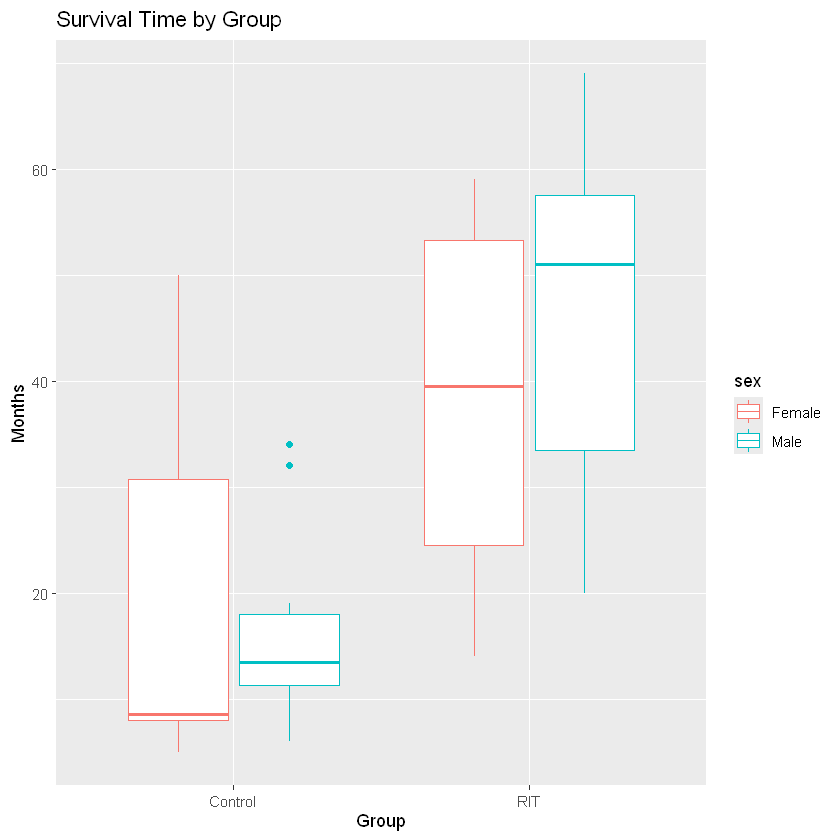

In [15]:
# EDA: Boxplot of survival

ggplot(glioma, aes(x = group, y = time)) +
geom_boxplot(notch = FALSE, aes(colour = sex)) +
labs(title = "Survival Time by Group",
       x = "Group",
       y = "Months")

There does seem to be an effect of group on survival time, with the radioimmunotherapy group having a higher median survival time than the control group. A sex-related effect does not seem present.
  

Looking at the box and whisker plot, there seems to be an issue with the assumption of normality. Let's test the normality of the data using the Shapiro-Wilk test:
  
**Shapiro-Wilk test for normality**

* **$H_{0}$ : The data are normally distributed**
* **$H_{A}$ : The data are not normally distributed**
* **(seperate hypotheses for sex and group)**

In [16]:
shapiro.test(glioma$tim[glioma$group == "Control"])


	Shapiro-Wilk normality test

data:  glioma$tim[glioma$group == "Control"]
W = 0.80087, p-value = 0.001563


In [17]:
shapiro.test(glioma$tim[glioma$group == "RIT"])


	Shapiro-Wilk normality test

data:  glioma$tim[glioma$group == "RIT"]
W = 0.92571, p-value = 0.1443


In [18]:
shapiro.test(glioma$tim[glioma$sex == "Female"])


	Shapiro-Wilk normality test

data:  glioma$tim[glioma$sex == "Female"]
W = 0.87292, p-value = 0.03016


In [19]:
shapiro.test(glioma$tim[glioma$sex == "Male"])


	Shapiro-Wilk normality test

data:  glioma$tim[glioma$sex == "Male"]
W = 0.90727, p-value = 0.04852


The *p-values* are less than 0.05 for the control group and for both sexes, indicating that the data are not normally distributed. We will use non-parametric tests to compare the survival times between the two groups within the factors.


We must also check the homogeneity of variances using Levene's test:
* **$H_{0}$ : The variances are equal**
* **$H_{A}$ : The variances are not equal**

In [20]:
car::leveneTest(time ~ group, data = glioma)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,1.52743,0.2247294
,35,NA,NA


In [21]:
car::leveneTest(time ~ sex, data = glioma)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,0.006877953,0.934377
,35,NA,NA


Variances are the same everywhere; nevertheless, due to the non-normal data, we will have to use a non-parametric test.


We will check for differences between groups formally using the Kruskal-Wallis test:
  
**Kruskal-Wallis test**
* **$H_{0}$: The medians of the groups are equal**
* **$H_{A}$: At least one median is different**
* **(to be stated separately for group and sex)**

In [23]:
kruskal.test(time ~ group, data = glioma)


	Kruskal-Wallis rank sum test

data:  time by group
Kruskal-Wallis chi-squared = 16.123, df = 1, p-value = 5.936e-05


In [24]:
kruskal.test(time ~ sex, data = glioma)


	Kruskal-Wallis rank sum test

data:  time by sex
Kruskal-Wallis chi-squared = 0.54251, df = 1, p-value = 0.4614


The p-value is less than 0.05, indicating that there is a significant difference in survival time between the two groups. We reject the null hypothesis and conclude that the medians of the groups are not equal, but we do not reject the $H_{0}$ for sex differences.

  
We cannot do a formal stats test to look for significant interaction terms between sex and group due to the non-normality of the data (i.e. there is not non-parametric equivalent for a two-way ANOVA); However, we can simply look at the box-and-whisker plot: there does not seem to be a significant interaction as the response is the same regardless of sex within each group.

### b. Age and Histology Interaction on Survival Time

`geom_smooth()` using formula = 'y ~ x'


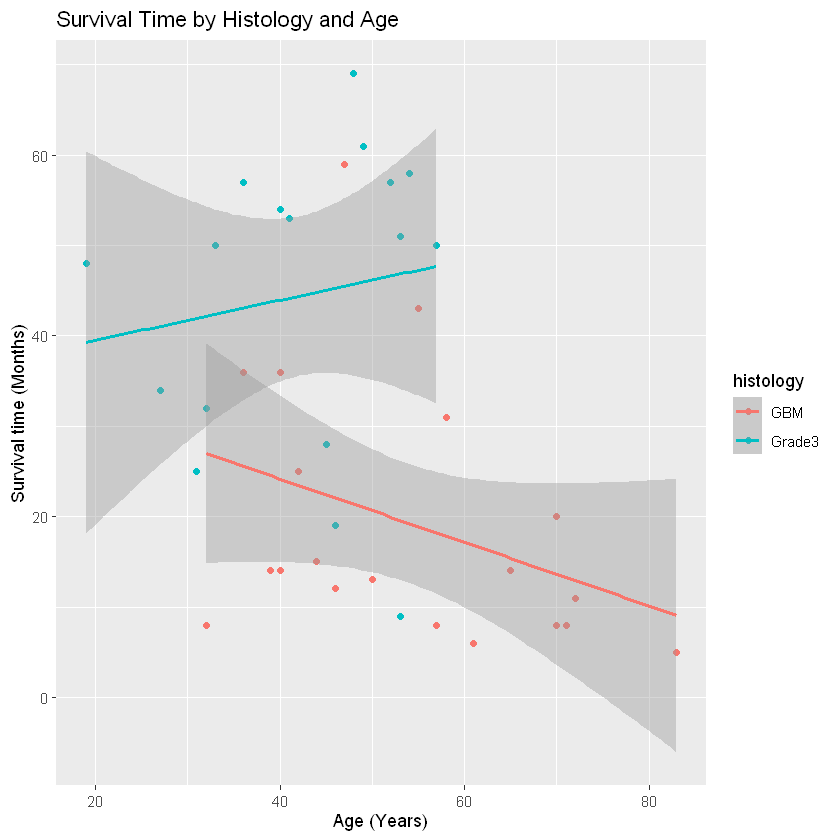

In [25]:
# EDA: Line/scatterplot of survival by histology and age

ggplot(glioma, aes(x = age, y = time)) +
geom_point(aes(colour = histology)) +
geom_smooth(method = "lm", se = TRUE, aes(colour = histology)) +
labs(title = "Survival Time by Histology and Age",
    x = "Age (Years)",
    y = "Survival time (Months)")

There does not seem to be a clear effect of age on survival time within each histology group. Notice the wide confidence intervals at the starts and ends of the age range for each histology group: the starts and ends overlap within each group suggesting a statistically insignificant effect of age


We can test formally with a linear model:
   
**Linear model**
* **$H_{0}$ : There is no interaction between age and histology**
* **$H_{A}$ : There is an interaction between age and histology**

In [26]:
model.lm <- lm(time ~ age * histology, data = glioma)
summary(model.lm)


Call:
lm(formula = time ~ age * histology, data = glioma)

Residuals:
    Min      1Q  Median      3Q     Max 
-37.830 -10.163  -1.397  10.392  37.274 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)   
(Intercept)          38.2531    13.7074   2.791  0.00867 **
age                  -0.3516     0.2461  -1.429  0.16239   
histologyGrade3      -3.2009    20.5856  -0.155  0.87738   
age:histologyGrade3   0.5739     0.4308   1.332  0.19194   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 15.48 on 33 degrees of freedom
Multiple R-squared:  0.4464,	Adjusted R-squared:  0.396 
F-statistic: 8.869 on 3 and 33 DF,  p-value: 0.0001877


Before we can interpret the linear model fit, we must check that the linear model is indeed suited to the data. We can do this by checking the residuals:

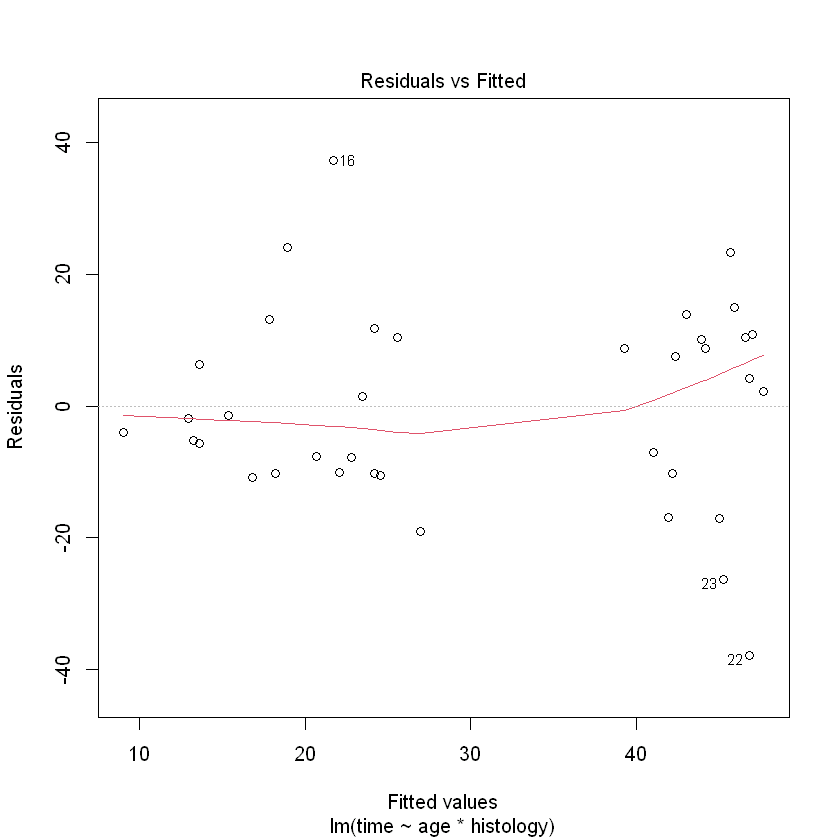

In [27]:
# Residuals vs Fitted plot
plot(model.lm, which = 1)

Or you could check normality of residuals with a QQ plot:

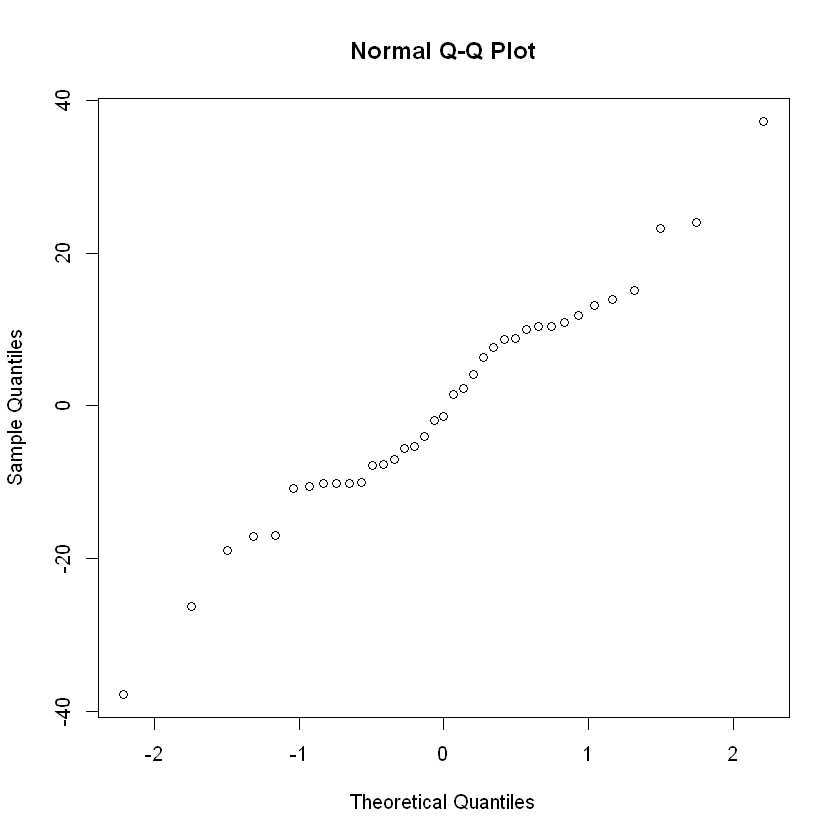

In [28]:
# Normal Q-Q plot

qqnorm(model.lm$residuals)

Or you could check for homogeneity of variances with a residuals vs fitted plot:

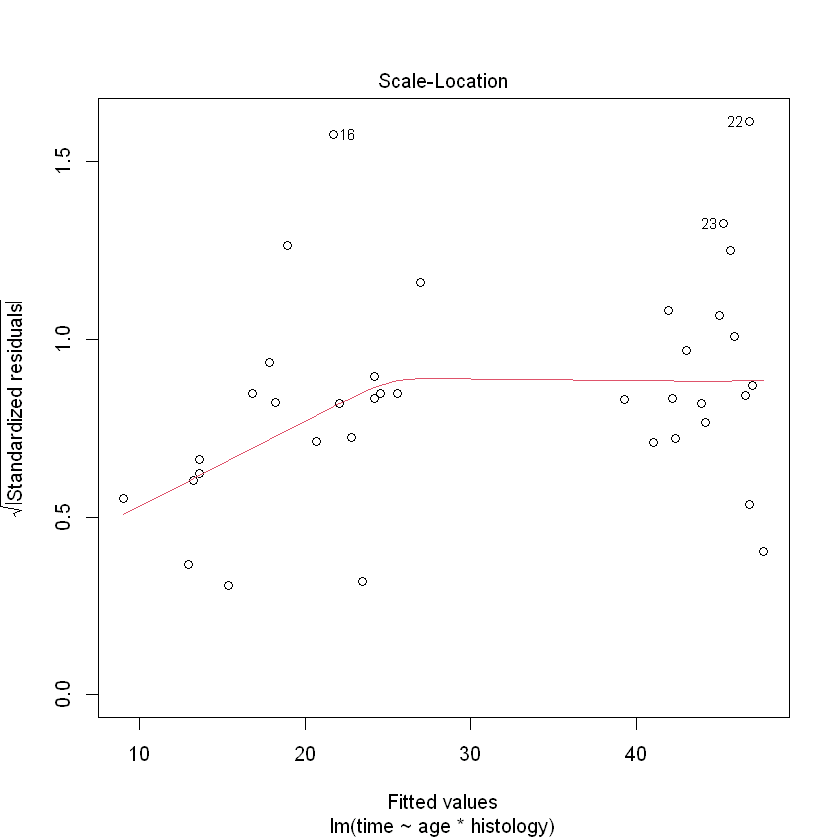

In [29]:
# Residuals vs Fitted plot
  
plot(model.lm, which = 3)

Or simply assess the normality of the residuals with a Shapiro-Wilk test:

In [31]:
# Shapiro-Wilk test for normality
  
glioma$residuals <- model.lm$residuals

shapiro.test(glioma$residuals[glioma$group == "RIT"])


	Shapiro-Wilk normality test

data:  glioma$residuals[glioma$group == "RIT"]
W = 0.93321, p-value = 0.1984


In [32]:
shapiro.test(glioma$residuals[glioma$group == "Control"])


	Shapiro-Wilk normality test

data:  glioma$residuals[glioma$group == "Control"]
W = 0.90444, p-value = 0.0687


Okay, residuals are normal according to most tests above. The interaction term is not significant, indicating that there is no interaction between age and histology on survival time.
  

We will use the Kruskal-Wallis test to compare survival times between the different histology groups:
  
**Kruskal-Wallis test**
* **$H_{0}$ : The medians of the histology groups are equal**
* **$H_{A}$ : At least one median is different**

In [33]:
kruskal.test(time ~ histology, data = glioma)


	Kruskal-Wallis rank sum test

data:  time by histology
Kruskal-Wallis chi-squared = 13.74, df = 1, p-value = 0.0002099


The p-value is less than 0.05, indicating that there is a significant difference in survival time between the histology groups. We reject the null hypothesis and conclude that the medians of the histology groups are not equal.
  

We cannot do a formal stats test to look for significant interaction terms between age and histology due to the non-normality of the data; However, we can simply look at the box-and-whisker plot: there does not seem to be a significant interaction as the response is the same regardless of age within each histology group.
  

Or we can test with an ANCOVA instead of the linear model above (start first with the assumption of normality and variances within the histology groups - Levene's test and Shapiro-Wilk's test)

In [34]:
model.aov1 <- aov(time ~ histology * age, data = glioma)
summary(model.aov1)

              Df Sum Sq Mean Sq F value   Pr(>F)    
histology      1   5795    5795  24.169 2.36e-05 ***
age            1    159     159   0.662    0.422    
histology:age  1    425     425   1.775    0.192    
Residuals     33   7912     240                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

The outcome is the same as the linear model above: there is no interaction between age and histology on survival time.